# GNN Testing

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.fft

# We use PyTorch Geometric (PyG) for handling graph data
try:
    from torch_geometric.nn import GATConv
    from torch_geometric.data import Data
except ImportError:
    print("Please install torch_geometric: pip install torch-geometric")

class TweezerGNN(nn.Module):
    def __init__(self, hidden_dim=64):
        super(TweezerGNN, self).__init__()
        
        # We use Graph Attention Networks (GAT). 
        # Attention allows traps to learn *which* neighbors cause the most optical cross-talk.
        self.conv1 = GATConv(in_channels=2, out_channels=hidden_dim, heads=4, concat=True)
        self.conv2 = GATConv(in_channels=hidden_dim * 4, out_channels=hidden_dim, heads=4, concat=True)
        
        # Final linear layers to output our weights (w) and phases (phi)
        self.fc_out = nn.Linear(hidden_dim * 4, 2)
        
        # Activation functions
        self.elu = nn.ELU()
        
    def forward(self, x, edge_index):
        # x shape: [N_traps, 2] -> containing continuous (x_j, y_j) coordinates
        # edge_index shape: [2, num_edges] -> defining which traps are neighbors
        
        # Pass 1: Look at immediate neighbors
        h = self.conv1(x, edge_index)
        h = self.elu(h)
        
        # Pass 2: Look at neighbors of neighbors (broader cross-talk)
        h = self.conv2(h, edge_index)
        h = self.elu(h)
        
        # Output prediction
        out = self.fc_out(h)
        
        # Split outputs
        # Weights should be positive (e.g., Sigmoid to keep between 0 and 1)
        w = torch.sigmoid(out[:, 0]) 
        # Phases should be between -pi and pi
        phi = torch.tanh(out[:, 1]) * torch.pi 
        
        return w, phi

class PhysicsInformedLoss(nn.Module):
    def __init__(self):
        super(PhysicsInformedLoss, self).__init__()
        # Exact Hardware Parameters
        self.res = 1024
        self.pixel_size = 16e-6      # 16 microns in meters
        self.wavelength = 852e-9     # 852 nm in meters
        self.focal_length = 17.3e-3  # 17.3 mm in meters
        
        # Calculate physical spans
        self.L_slm = self.res * self.pixel_size
        
        # Calculate focal plane pixel size (Fraunhofer approximation)
        # dx_foc = (lambda * f) / L_slm
        self.dx_foc = (self.wavelength * self.focal_length) / self.L_slm
        self.W_foc = self.res * self.dx_foc # Total physical width of simulated camera
        
    def forward(self, trap_coords_um, predicted_w, predicted_phi):
        """
        Simulates the physical propagation of light from the SLM to the focal plane.
        """
        device = trap_coords_um.device
        N = trap_coords_um.size(0)
        
        # Convert requested trap coordinates from microns to meters
        trap_coords_m = trap_coords_um * 1e-6
        
        # Create physical X, Y coordinates for every pixel on the SLM screen
        # indexing='xy' ensures X corresponds to columns and Y to rows (standard image format)
        lim = self.L_slm / 2.0
        coords1d = torch.linspace(-lim, lim, self.res, device=device)
        X_slm, Y_slm = torch.meshgrid(coords1d, coords1d, indexing='xy')
        
        complex_field = torch.zeros((self.res, self.res), dtype=torch.complex64, device=device)
        
        # Precompute the k-vector scaling factor: 2pi / (lambda * f)
        k_factor = (2 * torch.pi) / (self.wavelength * self.focal_length)
        
        # We use a loop here to save GPU VRAM. Broadcasting 400 traps over a 1024x1024 
        # grid simultaneously would require ~3.5GB just for this one step. 
        # A loop keeps it well under 1GB, easily handled by your 5090x.
        for j in range(N):
            # Calculate the linear grating tilt for this specific trap
            tilt = k_factor * (trap_coords_m[j, 0] * X_slm + trap_coords_m[j, 1] * Y_slm)
            # Add to the global complex interference field
            term = predicted_w[j] * torch.exp(1j * (tilt + predicted_phi[j]))
            complex_field = complex_field + term
            
        # The physical SLM applies only the phase, discarding amplitude
        slm_phase_mask = torch.exp(1j * torch.angle(complex_field))
        
        # 2D FFT physically simulates the 17.3mm objective lens focusing the light
        focal_plane_complex = torch.fft.fftshift(torch.fft.fft2(slm_phase_mask))
        focal_intensity = torch.abs(focal_plane_complex)**2
        
        # PyTorch grid_sample requires coordinates normalized between -1 and 1.
        # We map the physical meters back into the [-1, 1] simulation window.
        norm_coords = trap_coords_m / (self.W_foc / 2.0)
        
        # Reshape for grid_sample: [Batch, Height, Width, (x,y)]
        sample_coords = norm_coords.view(1, 1, N, 2) 
        intensity_img = focal_intensity.view(1, 1, self.res, self.res)
        
        # Extract the exact sub-pixel intensity at the requested (x_j, y_j) targets
        trap_intensities = F.grid_sample(intensity_img, sample_coords, 
                                         mode='bilinear', align_corners=True)
        trap_intensities = trap_intensities.view(N)
        
        # Physics Loss: We want low variance (uniformity) and high mean (efficiency)
        variance = torch.var(trap_intensities)
        mean_intensity = torch.mean(trap_intensities)
        
        loss = (variance / mean_intensity) - (0.01 * mean_intensity)
        return loss

def build_knn_edges(coords, k=9):
    """Helper to build the graph edges dynamically in pure PyTorch."""
    N_traps = coords.size(0)
    device = coords.device
    
    actual_k = min(k, N_traps)
    dist_matrix = torch.cdist(coords, coords)
    _, knn_indices = torch.topk(dist_matrix, k=actual_k, largest=False)
    
    source_nodes = torch.arange(N_traps, device=device).view(-1, 1).repeat(1, actual_k).flatten()
    target_nodes = knn_indices.flatten()
    
    mask = source_nodes != target_nodes
    edge_index = torch.stack([source_nodes[mask], target_nodes[mask]])
    return edge_index

def train_gnn(iterations=2000, save_path="tweezer_gnn.pth"):
    """Trains the model completely unsupervised using exact optical physics."""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Starting physics-informed training on {device}...")
    
    model = TweezerGNN().to(device)
    physics_loss_fn = PhysicsInformedLoss().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    
    model.train()
    for step in range(iterations):
        # 1. Randomly decide how many traps this specific training step will use
        N_traps = torch.randint(low=50, high=250, size=(1,)).item()
        
        # 2. Generate a physically realistic 5 micron grid
        trap_spacing = 5.0 # microns
        grid_side = int(N_traps**0.5) + 3 
        
        x_vals = torch.arange(grid_side, dtype=torch.float32) * trap_spacing
        y_vals = torch.arange(grid_side, dtype=torch.float32) * trap_spacing
        x_vals -= (grid_side - 1) * trap_spacing / 2.0
        y_vals -= (grid_side - 1) * trap_spacing / 2.0
        
        X, Y = torch.meshgrid(x_vals, y_vals, indexing='xy')
        all_coords = torch.stack([X.flatten(), Y.flatten()], dim=1)
        
        # Simulate missing atoms/defects by randomly sub-sampling the perfect grid
        indices = torch.randperm(all_coords.size(0))[:N_traps]
        coords_um = all_coords[indices].to(device) # Inputs in exact microns!
        
        # 3. Build graph
        edge_index = build_knn_edges(coords_um)
        
        # 4. GNN Forward Pass
        optimizer.zero_grad()
        predicted_w, predicted_phi = model(coords_um, edge_index)
        
        # 5. Physics Loss and Backprop
        loss = physics_loss_fn(coords_um, predicted_w, predicted_phi)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        if step % 50 == 0:
            print(f"Step {step:04d}/{iterations} | Traps: {N_traps:03d} | Loss: {loss.item():.6f}")

    torch.save(model.state_dict(), save_path)
    print(f"Training complete. Model saved to {save_path}")

def get_optimized_phases(coords_list, model_path="tweezer_gnn.pth"):
    """
    Loads the trained model and computes w and phi for a specific target array.
    This is the function you call during the actual quantum experiment.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 1. Initialize model and load trained weights
    model = TweezerGNN().to(device)
    try:
        model.load_state_dict(torch.load(model_path, weights_only=True))
    except FileNotFoundError:
        print(f"Error: Could not find {model_path}. You must run train_gnn() first!")
        return None, None
        
    model.eval() # Set model to evaluation mode (turns off dropout/batchnorm updates)
    
    # 2. Format the user's input coordinates
    # Convert standard Python lists or numpy arrays to PyTorch tensors
    coords = torch.tensor(coords_list, dtype=torch.float32).to(device)
    
    # 3. Build the graph for this specific input
    edge_index = build_knn_edges(coords)
    
    # 4. Perform the prediction incredibly fast, without tracking gradients
    with torch.no_grad():
        w, phi = model(coords, edge_index)
        
    # Return standard numpy arrays so your SLM driver or other Python code can easily use them
    return w.cpu().numpy(), phi.cpu().numpy()

if __name__ == "__main__":
    # Step 1: Train the network (you only need to do this once)
    print("--- PHASE 1: TRAINING ---")
    train_gnn(iterations=500, save_path="test_model.pth")
    
    # Step 2: Use the network (you do this every time the array needs updating)
    print("\n--- PHASE 2: INFERENCE ---")
    # Example: We want to generate a specific 5-trap layout
    target_coords = [
        [-5.0, -5.0],
        [-5.0,  5.0],
        [ 5.0, -5.0],
        [ 5.0,  5.0]
    ]
    
    print("Requesting optimized phases for a 5-trap array...")
    weights, phases = get_optimized_phases(target_coords, model_path="test_model.pth")
    
    if weights is not None:
        print("\nPredicted Amplitude Weights (w):")
        print(weights)
        print("\nPredicted Phases (phi, in radians):")
        print(phases)

--- PHASE 1: TRAINING ---
Starting physics-informed training on cpu...
Step 0000/500 | Traps: 233 | Loss: 801717568.000000
Step 0050/500 | Traps: 196 | Loss: 569772544.000000
Step 0100/500 | Traps: 143 | Loss: 1038446528.000000
Step 0150/500 | Traps: 169 | Loss: 421498208.000000
Step 0200/500 | Traps: 080 | Loss: 1339081856.000000
Step 0250/500 | Traps: 167 | Loss: 447066976.000000
Step 0300/500 | Traps: 065 | Loss: 2222169344.000000


KeyboardInterrupt: 

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.fft

try:
    from torch_geometric.nn import GATConv
    from torch_geometric.data import Data
except ImportError:
    print("Please install torch_geometric: pip install torch-geometric")

class TweezerGNN(nn.Module):
    def __init__(self, hidden_dim=64):
        super(TweezerGNN, self).__init__()
        
        # We use Graph Attention Networks (GAT). 
        self.conv1 = GATConv(in_channels=2, out_channels=hidden_dim, heads=4, concat=True)
        self.conv2 = GATConv(in_channels=hidden_dim * 4, out_channels=hidden_dim, heads=4, concat=True)
        
        # Final linear layers to output our weights (w) and phases (phi)
        self.fc_out = nn.Linear(hidden_dim * 4, 2)
        self.elu = nn.ELU()
        
    def forward(self, x, edge_index):
        # Pass 1: Look at neighbors within the 10 micron radius
        h = self.conv1(x, edge_index)
        h = self.elu(h)
        
        # Pass 2: Look at neighbors of neighbors
        h = self.conv2(h, edge_index)
        h = self.elu(h)
        
        out = self.fc_out(h)
        
        # w bounded 0.1 to 1.0 (prevents traps from turning off entirely)
        w = torch.sigmoid(out[:, 0]) * 0.9 + 0.1 
        phi = torch.tanh(out[:, 1]) * torch.pi 
        
        return w, phi

class PhysicsInformedLoss(nn.Module):
    def __init__(self):
        super(PhysicsInformedLoss, self).__init__()
        # Exact Hardware Parameters
        self.res = 1024
        self.pixel_size = 16e-6      
        self.wavelength = 852e-9     
        self.focal_length = 17.3e-3  
        
        self.L_slm = self.res * self.pixel_size
        self.dx_foc = (self.wavelength * self.focal_length) / self.L_slm
        self.W_foc = self.res * self.dx_foc 
        
    def forward(self, trap_coords_um, predicted_w, predicted_phi):
        """Simulates the physical propagation of light from SLM to focal plane."""
        device = trap_coords_um.device
        N = trap_coords_um.size(0)
        
        trap_coords_m = trap_coords_um * 1e-6
        lim = self.L_slm / 2.0
        coords1d = torch.linspace(-lim, lim, self.res, device=device)
        X_slm, Y_slm = torch.meshgrid(coords1d, coords1d, indexing='xy')
        
        complex_field = torch.zeros((self.res, self.res), dtype=torch.complex64, device=device)
        k_factor = (2 * torch.pi) / (self.wavelength * self.focal_length)
        
        for j in range(N):
            tilt = k_factor * (trap_coords_m[j, 0] * X_slm + trap_coords_m[j, 1] * Y_slm)
            term = predicted_w[j] * torch.exp(1j * (tilt + predicted_phi[j]))
            complex_field = complex_field + term
            
        slm_phase_mask = torch.exp(1j * torch.angle(complex_field))
        
        focal_plane_complex = torch.fft.fftshift(torch.fft.fft2(slm_phase_mask))
        focal_intensity = torch.abs(focal_plane_complex)**2
        
        norm_coords = trap_coords_m / (self.W_foc / 2.0)
        sample_coords = norm_coords.view(1, 1, N, 2) 
        intensity_img = focal_intensity.view(1, 1, self.res, self.res)
        
        trap_intensities = F.grid_sample(intensity_img, sample_coords, 
                                         mode='bilinear', align_corners=True)
        trap_intensities = trap_intensities.view(N)
        
        # CHANGED: Use Standard Deviation instead of Variance for gradient stability
        std_dev = torch.std(trap_intensities)
        mean_intensity = torch.mean(trap_intensities)
        
        # Coefficient of Variation (ideal target is 0.0)
        cv = std_dev / (mean_intensity + 1e-8) 
        
        return cv

def build_radius_edges(coords, radius_um=10.0):
    dist_matrix = torch.cdist(coords, coords)
    mask = (dist_matrix <= radius_um) & (dist_matrix > 0.0001)
    source_nodes, target_nodes = torch.where(mask)
    edge_index = torch.stack([source_nodes, target_nodes])
    return edge_index

def generate_random_array(device, min_traps=50, max_traps=250):
    """Helper to generate a random tweezer array."""
    N_traps = torch.randint(low=min_traps, high=max_traps, size=(1,)).item()
    trap_spacing = 5.0 
    grid_side = int(N_traps**0.5) + 3 
    
    x_vals = torch.arange(grid_side, dtype=torch.float32) * trap_spacing
    y_vals = torch.arange(grid_side, dtype=torch.float32) * trap_spacing
    x_vals -= (grid_side - 1) * trap_spacing / 2.0
    y_vals -= (grid_side - 1) * trap_spacing / 2.0
    
    X, Y = torch.meshgrid(x_vals, y_vals, indexing='xy')
    all_coords = torch.stack([X.flatten(), Y.flatten()], dim=1)
    
    indices = torch.randperm(all_coords.size(0))[:N_traps]
    return all_coords[indices].to(device)

def train_gnn(iterations=2000, save_path="tweezer_gnn.pth"):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Starting physics-informed training on {device}...")
    
    model = TweezerGNN().to(device)
    physics_loss_fn = PhysicsInformedLoss().to(device)
    
    # Lowered learning rate for stability
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001) 
    
    # NEW: Generate a static benchmark array to accurately track progress
    benchmark_coords = generate_random_array(device, min_traps=150, max_traps=151)
    benchmark_edges = build_radius_edges(benchmark_coords, radius_um=10.0)
    
    model.train()
    for step in range(iterations):
        # 1. Train on a completely new random array
        coords_um = generate_random_array(device)
        edge_index = build_radius_edges(coords_um, radius_um=10.0)
        
        optimizer.zero_grad()
        predicted_w, predicted_phi = model(coords_um, edge_index)
        
        loss = physics_loss_fn(coords_um, predicted_w, predicted_phi)
        loss.backward()
        
        # Gradient clipping prevents massive spikes from ruining the weights
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # 2. Every 25 steps, evaluate on the static benchmark array
        if step % 25 == 0:
            with torch.no_grad():
                bench_w, bench_phi = model(benchmark_coords, benchmark_edges)
                bench_loss = physics_loss_fn(benchmark_coords, bench_w, bench_phi)
            
            print(f"Step {step:04d}/{iterations} | "
                  f"Train Batch Loss: {loss.item():.4f} | "
                  f"Static Benchmark Loss: {bench_loss.item():.4f}")

    torch.save(model.state_dict(), save_path)
    print(f"Training complete. Model saved to {save_path}")

def get_optimized_phases(coords_list, model_path="tweezer_gnn.pth"):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = TweezerGNN().to(device)
    try:
        model.load_state_dict(torch.load(model_path, weights_only=True))
    except FileNotFoundError:
        print(f"Error: Could not find {model_path}.")
        return None, None
        
    model.eval() 
    coords = torch.tensor(coords_list, dtype=torch.float32).to(device)
    edge_index = build_radius_edges(coords, radius_um=10.0)
    
    with torch.no_grad():
        w, phi = model(coords, edge_index)
        
    return w.cpu().numpy(), phi.cpu().numpy()

if __name__ == "__main__":
    train_gnn(iterations=1000, save_path="test_model.pth")

Starting physics-informed training on cpu...
Step 0000/1000 | Train Batch Loss: 0.7932 | Static Benchmark Loss: 1.0261
Step 0025/1000 | Train Batch Loss: 0.9333 | Static Benchmark Loss: 0.8257
Step 0050/1000 | Train Batch Loss: 0.7506 | Static Benchmark Loss: 0.8329
Step 0075/1000 | Train Batch Loss: 0.8714 | Static Benchmark Loss: 0.8760
Step 0100/1000 | Train Batch Loss: 0.6559 | Static Benchmark Loss: 0.9592
Step 0125/1000 | Train Batch Loss: 1.1778 | Static Benchmark Loss: 0.9074
Step 0150/1000 | Train Batch Loss: 0.8358 | Static Benchmark Loss: 0.8132
Step 0175/1000 | Train Batch Loss: 0.8974 | Static Benchmark Loss: 0.7372
Step 0200/1000 | Train Batch Loss: 0.8044 | Static Benchmark Loss: 0.7392
Step 0225/1000 | Train Batch Loss: 0.7915 | Static Benchmark Loss: 0.9154
Step 0250/1000 | Train Batch Loss: 0.9032 | Static Benchmark Loss: 0.8412
Step 0275/1000 | Train Batch Loss: 0.8572 | Static Benchmark Loss: 0.8413
Step 0300/1000 | Train Batch Loss: 0.6407 | Static Benchmark Loss: 

KeyboardInterrupt: 

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.fft

try:
    from torch_geometric.nn import GATConv
    from torch_geometric.data import Data
except ImportError:
    print("Please install torch_geometric: pip install torch-geometric")

class TweezerGNN(nn.Module):
    def __init__(self, hidden_dim=64):
        super(TweezerGNN, self).__init__()
        
        # We use Graph Attention Networks (GAT). 
        self.conv1 = GATConv(in_channels=2, out_channels=hidden_dim, heads=4, concat=True)
        self.conv2 = GATConv(in_channels=hidden_dim * 4, out_channels=hidden_dim, heads=4, concat=True)
        
        # Final linear layers to output our weights (w) and phases (phi)
        self.fc_out = nn.Linear(hidden_dim * 4, 2)
        self.elu = nn.ELU()
        
    def forward(self, x, edge_index):
        # Pass 1: Look at neighbors within the 10 micron radius
        h = self.conv1(x, edge_index)
        h = self.elu(h)
        
        # Pass 2: Look at neighbors of neighbors
        h = self.conv2(h, edge_index)
        h = self.elu(h)
        
        out = self.fc_out(h)
        
        # w bounded 0.1 to 1.0 (prevents traps from turning off entirely)
        w = torch.sigmoid(out[:, 0]) * 0.9 + 0.1 
        phi = torch.tanh(out[:, 1]) * torch.pi 
        
        return w, phi

class PhysicsInformedLoss(nn.Module):
    def __init__(self):
        super(PhysicsInformedLoss, self).__init__()
        # Exact Hardware Parameters
        self.res = 1024
        self.pixel_size = 16e-6      
        self.wavelength = 852e-9     
        self.focal_length = 17.3e-3  
        
        self.L_slm = self.res * self.pixel_size
        self.dx_foc = (self.wavelength * self.focal_length) / self.L_slm
        self.W_foc = self.res * self.dx_foc 
        
    def forward(self, trap_coords_um, predicted_w, predicted_phi):
        """Simulates the physical propagation of light from SLM to focal plane."""
        device = trap_coords_um.device
        N = trap_coords_um.size(0)
        
        trap_coords_m = trap_coords_um * 1e-6
        lim = self.L_slm / 2.0
        coords1d = torch.linspace(-lim, lim, self.res, device=device)
        X_slm, Y_slm = torch.meshgrid(coords1d, coords1d, indexing='xy')
        
        complex_field = torch.zeros((self.res, self.res), dtype=torch.complex64, device=device)
        k_factor = (2 * torch.pi) / (self.wavelength * self.focal_length)
        
        for j in range(N):
            tilt = k_factor * (trap_coords_m[j, 0] * X_slm + trap_coords_m[j, 1] * Y_slm)
            term = predicted_w[j] * torch.exp(1j * (tilt + predicted_phi[j]))
            complex_field = complex_field + term
            
        slm_phase_mask = torch.exp(1j * torch.angle(complex_field))
        
        focal_plane_complex = torch.fft.fftshift(torch.fft.fft2(slm_phase_mask))
        focal_intensity = torch.abs(focal_plane_complex)**2
        
        norm_coords = trap_coords_m / (self.W_foc / 2.0)
        sample_coords = norm_coords.view(1, 1, N, 2) 
        intensity_img = focal_intensity.view(1, 1, self.res, self.res)
        
        trap_intensities = F.grid_sample(intensity_img, sample_coords, 
                                         mode='bilinear', align_corners=True)
        trap_intensities = trap_intensities.view(N)
        
        # CHANGED: Use Standard Deviation instead of Variance for gradient stability
        std_dev = torch.std(trap_intensities)
        mean_intensity = torch.mean(trap_intensities)
        
        # Coefficient of Variation (ideal target is 0.0)
        cv = std_dev / (mean_intensity + 1e-8) 
        
        return cv

def build_radius_edges(coords, radius_um=10.0):
    dist_matrix = torch.cdist(coords, coords)
    mask = (dist_matrix <= radius_um) & (dist_matrix > 0.0001)
    source_nodes, target_nodes = torch.where(mask)
    edge_index = torch.stack([source_nodes, target_nodes])
    return edge_index

def generate_regular_grid_array(device, max_size=16):
    """
    Generates a regular NxM tweezer array centered at (0,0).
    Grid spacing is randomized between 3 and 10 microns per batch.
    Grid dimensions N and M are randomized up to max_size.
    """
    # 1. Randomize the array dimensions (e.g., a 4x12 array, or 16x16)
    N_cols = torch.randint(low=2, high=max_size + 1, size=(1,)).item()
    M_rows = torch.randint(low=2, high=max_size + 1, size=(1,)).item()
    
    # 2. Randomize the regular spacing between 3 and 10 microns
    trap_spacing = torch.empty(1).uniform_(3.0, 10.0).item()
    
    # 3. Build the regular grid centered on 0,0
    x_vals = torch.arange(N_cols, dtype=torch.float32) * trap_spacing
    y_vals = torch.arange(M_rows, dtype=torch.float32) * trap_spacing
    
    # Center the grid
    x_vals -= (N_cols - 1) * trap_spacing / 2.0
    y_vals -= (M_rows - 1) * trap_spacing / 2.0
    
    X, Y = torch.meshgrid(x_vals, y_vals, indexing='xy')
    all_coords = torch.stack([X.flatten(), Y.flatten()], dim=1)
    
    # Optional: Randomly drop 5% of traps to simulate missing atoms/defects
    # This prevents the GNN from over-fitting to perfect rectangles
    N_total = all_coords.size(0)
    num_keep = int(N_total * torch.empty(1).uniform_(0.90, 1.0).item())
    indices = torch.randperm(N_total)[:num_keep]
    
    return all_coords[indices].to(device)

def train_gnn(iterations=2000, save_path="tweezer_gnn.pth"):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Starting physics-informed training on {device}...")
    
    model = TweezerGNN().to(device)
    physics_loss_fn = PhysicsInformedLoss().to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001) 
    
    # Generate a static 10x10 benchmark array with 5 micron spacing
    bench_x = torch.arange(10, dtype=torch.float32) * 5.0
    bench_x -= (10 - 1) * 5.0 / 2.0
    bench_X, bench_Y = torch.meshgrid(bench_x, bench_x, indexing='xy')
    benchmark_coords = torch.stack([bench_X.flatten(), bench_Y.flatten()], dim=1).to(device)
    
    # Set the graph radius to 11 microns to catch nearest and diagonal neighbors
    # (Diagonals for 10um spacing = 14.1um, so we stick to 1.5x max spacing)
    radius_cutoff = 15.0 
    benchmark_edges = build_radius_edges(benchmark_coords, radius_um=radius_cutoff)
    
    model.train()
    for step in range(iterations):
        # 1. Train on a new NxM regular array
        coords_um = generate_regular_grid_array(device, max_size=16)
        edge_index = build_radius_edges(coords_um, radius_um=radius_cutoff)
        
        optimizer.zero_grad()
        predicted_w, predicted_phi = model(coords_um, edge_index)
        
        loss = physics_loss_fn(coords_um, predicted_w, predicted_phi)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        if step % 25 == 0:
            with torch.no_grad():
                bench_w, bench_phi = model(benchmark_coords, benchmark_edges)
                bench_loss = physics_loss_fn(benchmark_coords, bench_w, bench_phi)
            
            print(f"Step {step:04d}/{iterations} | "
                  f"Edges: {edge_index.size(1):04d} | "
                  f"Batch Loss: {loss.item():.4f} | "
                  f"Benchmark Loss (10x10): {bench_loss.item():.4f}")

    torch.save(model.state_dict(), save_path)
    print(f"Training complete. Model saved to {save_path}")

def get_optimized_phases(coords_list, model_path="tweezer_gnn.pth"):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = TweezerGNN().to(device)
    try:
        model.load_state_dict(torch.load(model_path, weights_only=True))
    except FileNotFoundError:
        print(f"Error: Could not find {model_path}.")
        return None, None
        
    model.eval() 
    coords = torch.tensor(coords_list, dtype=torch.float32).to(device)
    edge_index = build_radius_edges(coords, radius_um=10.0)
    
    with torch.no_grad():
        w, phi = model(coords, edge_index)
        
    return w.cpu().numpy(), phi.cpu().numpy()

if __name__ == "__main__":
    train_gnn(iterations=1000, save_path="test_model.pth")

Starting physics-informed training on cpu...
Step 0000/1000 | Edges: 4054 | Batch Loss: 1.9443 | Benchmark Loss (10x10): 2.0617
Step 0025/1000 | Edges: 1655 | Batch Loss: 1.2971 | Benchmark Loss (10x10): 1.3170
Step 0050/1000 | Edges: 1246 | Batch Loss: 1.0900 | Benchmark Loss (10x10): 1.2293
Step 0075/1000 | Edges: 0775 | Batch Loss: 1.8102 | Benchmark Loss (10x10): 1.7042
Step 0100/1000 | Edges: 0144 | Batch Loss: 0.7909 | Benchmark Loss (10x10): 1.1724
Step 0125/1000 | Edges: 0628 | Batch Loss: 0.8019 | Benchmark Loss (10x10): 1.7071
Step 0150/1000 | Edges: 0594 | Batch Loss: 1.1886 | Benchmark Loss (10x10): 1.6051
Step 0175/1000 | Edges: 3917 | Batch Loss: 1.4197 | Benchmark Loss (10x10): 1.3146
Step 0200/1000 | Edges: 0428 | Batch Loss: 0.8987 | Benchmark Loss (10x10): 1.2762
Step 0225/1000 | Edges: 0660 | Batch Loss: 1.4512 | Benchmark Loss (10x10): 1.4802
Step 0250/1000 | Edges: 0042 | Batch Loss: 0.6851 | Benchmark Loss (10x10): 1.3700
Step 0275/1000 | Edges: 3946 | Batch Loss:

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um
--- Target Generation ---
Grid: 15x15
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 3.14e-06 | Uniformity: 60.14% | Min/Max ratio: 0.128
Iteration 010 | Mean-Squared Error: 4.30e-08 | Uniformity: 95.33% | Min/Max ratio: 0.689
Iteration 020 | Mean-Squared Error: 7.14e-09 | Uniformity: 98.10% | Min/Max ratio: 0.893
Iteration 030 | Mean-Squared Error: 2.93e-09 | Uniformity: 98.78% | Min/Max ratio: 0.938
Iteration 040 | Mean-Squared Error: 1.71e-09 | Uniformity: 99.07% | Min/Max ratio: 0.951
Iteration 050 | Mean-Squared Error: 2.49e-09 | Uniformity: 98.88% | Min/Max ratio: 0.940
Iteration 060 | Mean-Squared Er

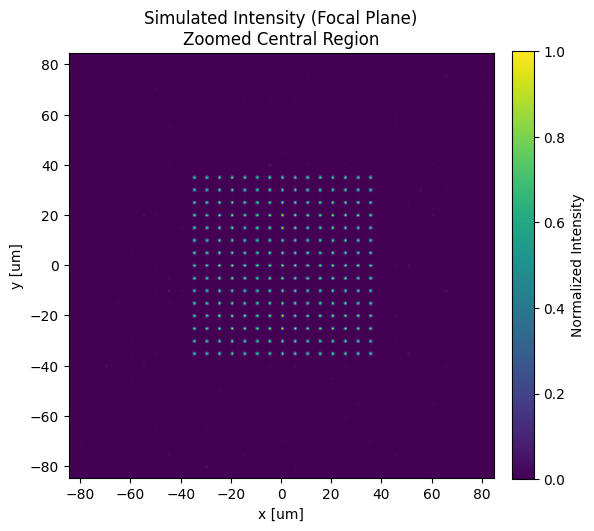

In [9]:
import pytweezer.phasemask as pm
import numpy as np

dx, dy = 8.0, 12.0
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

W1 = np.ones((15, 15))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0)

terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)

I_foc = PM.simulate_focal_plane(pm_array1, Nx_pad=2048, Ny_pad=2048, show=True, zoom_pixels=100, cmap='viridis')


In [10]:
 # The zip function naturally pairs the coordinates into [(x1, y1), (x2, y2), ...]
coords_list = list(zip(x_n, y_n))

# Pass the paired list into the GNN
w, phi = get_optimized_phases(coords_list, model_path="test_model.pth")

if w is not None:
    print("Successfully formatted coordinates and ran inference!")
    print(f"Input traps: {len(coords_list)}")
    print(f"Output weights shape: {w.shape} | Output phases shape: {phi.shape}")

Successfully formatted coordinates and ran inference!
Input traps: 225
Output weights shape: (225,) | Output phases shape: (225,)


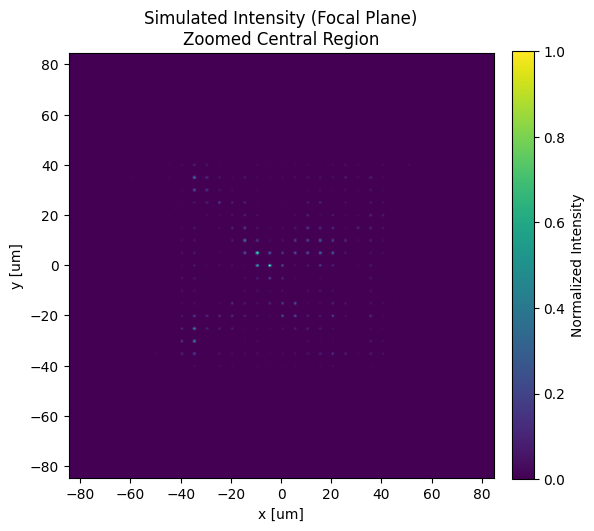

In [12]:
terms2 = [w, phi, x_n, y_n, array_shape]
pm_array2 = PM.generate_phasemask(terms2)
I_foc = PM.simulate_focal_plane(pm_array2, Nx_pad=2048, Ny_pad=2048, show=True, zoom_pixels=100, cmap='viridis')
